# ⚖️ 第 69 课 · 算子库 vs 编译器:专业厨师与万能厨师

> cuDNN/cuBLAS/CUTLASS(手写内核)vs Inductor/Triton(JIT 编译器)—— 各自优劣与实测对比

**章节**: 第 10 章 · AI 编译器原理

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解两类写 kernel 的路线:算子库(手工精调)vs JIT 编译器(自动生成)
- 掌握各自优劣:算子库覆盖常见算子且逼近硬件峰值;编译器灵活覆盖任意组合、可自动融合
- 实测矩阵乘 / 逐元素链 / softmax 三条路的延迟,得到真实对比数字
- 理解 cuBLAS 在矩阵乘上难被超越、而融合类编译器更快的机制原因
- 用 matplotlib / seaborn 可视化三类延迟对比
- 跑通配套 App:选择运算与方案看对比与建议

## 📑 本课目录

1. **直觉:专业厨师 vs 万能厨师** — 常见菜(算子库)又快又好,特殊菜(编译器)都能做
2. **两类路线对比** — 算子库 vs 编译器:覆盖、性能、灵活性、融合能力
3. **实测:三条路比延迟** — cuBLAS / 手写 Triton / Inductor 三种实现
4. **机制解释** — 为什么矩阵乘库难超越、融合类编译器更快
5. **配套 App** — app_69_oplib_vs_compiler.py:选择对比

## 🔗 参考资料

- [cuBLAS 文档](https://docs.nvidia.com/cuda/cublas/)
- [CUTLASS](https://github.com/NVIDIA/cutlass)
- [Triton](https://triton-lang.org/)
- [torch.compile](https://pytorch.org/docs/stable/torch.compiler.html)

🧊 本课开篇:KMP 保护 + 会议论文风格绘图头。

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # 避免 Anaconda/torch 的 OMP 库冲突(Windows)
import time, json, io, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
torch.set_float32_matmul_precision("high")              # 开启 TF32,加速并消除告警
print("torch =", torch.__version__,
      "| CUDA =", torch.cuda.is_available(),
      "| device =", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# ---------- 会议论文风格绘图:matplotlib + seaborn ----------
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]  # 中文
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200

torch = 2.11.0+cu128 | CUDA = True | device = NVIDIA GeForce RTX 5060 Laptop GPU


## 1️⃣ 直觉:专业厨师 vs 万能厨师 👨‍🍳

想做好菜有两种雇人方式:

- **专业厨师(算子库)**:cuDNN / cuBLAS / CUTLASS。只做那几道拿手菜(常见算子),但每道都练了
  多年、逼近硬件极限。缺点:菜单固定,你想吃的"融合菜"它不会做;
- **万能厨师(JIT 编译器)**:Triton / Inductor。什么菜都能现做(任意算子组合),还会帮你
  "几道并一锅"(自动融合)。缺点:常见大菜未必比得上专业厨师的秘方。

实际工程里两者**混用**:常见算子(矩阵乘、卷积)交给库,特殊/融合算子交给编译器。
这一课我们**实测**三条路,看看什么时候该请谁。

## 2️⃣ 两类路线对比 📋

| 维度 | 算子库(cuBLAS/cuDNN/CUTLASS) | JIT 编译器(Triton/Inductor) |
|---|---|---|
| 内核来源 | 工程师手工精调,覆盖常见算子 | 编译器自动生成,覆盖任意组合 |
| 常见算子性能 | 逼近硬件峰值 | 接近或略低于库 |
| 自定义/融合 | 难,需要手写新 kernel | 强,自动融合、自动调优 |
| 开发成本 | 高(每个算子单独调) | 低(写高层描述) |
| 更新/适配新硬件 | 需库维护者跟进 | 编译器重编译即可适配 |

**关键机制**:矩阵乘是 compute-bound、形态规整,cuBLAS 把它压到接近理论峰值,编译器很难再快;
而逐元素/融合类是 memory-bound,瓶颈在读写,编译器把中间结果留在芯片内、融合成一个大 kernel,
反而能大幅超过"每个算子各调一个库 kernel"。

⏱️ CUDA 计时工具。

In [2]:
def bench_cuda_ms(fn, warmup=10, repeat=50):
    """用 torch.cuda.Event 精确计时:返回平均单次耗时(ms)。fn 为无参可调用对象。"""
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    s = torch.cuda.Event(enable_timing=True)
    e = torch.cuda.Event(enable_timing=True)
    s.record()
    for _ in range(repeat):
        fn()
    e.record()
    torch.cuda.synchronize()
    return s.elapsed_time(e) / repeat

🎯 矩阵乘是算子库的主场:cuBLAS 逼近峰值,手写 Triton 与 Inductor 只能打平或略慢 —— 这正是『专业厨师』的价值。

In [3]:
import torch, triton, triton.language as tl

@triton.jit
def mm_k(a_ptr, b_ptr, c_ptr, M, Nn, K, sm, sk, bk, bn, cm, cn,
         BM: tl.constexpr, BN: tl.constexpr, BK: tl.constexpr):
    pm = tl.program_id(0); pn = tl.program_id(1)
    om = pm * BM + tl.arange(0, BM); on = pn * BN + tl.arange(0, BN); ok = tl.arange(0, BK)
    acc = tl.zeros((BM, BN), tl.float32)
    for k in range(0, K, BK):
        a = tl.load(a_ptr + om[:, None] * sm + (k + ok)[None, :] * sk)
        b = tl.load(b_ptr + (k + ok)[:, None] * bk + on[None, :] * bn)
        acc += tl.dot(a, b)
    tl.store(c_ptr + om[:, None] * cm + on[None, :] * cn, acc)

def run_mm(A, Bm, C, M, Nn, K, BM=128, BN=128, BK=32):
    mm_k[(triton.cdiv(M, BM), triton.cdiv(Nn, BN))](
        A, Bm, C, M, Nn, K, A.stride(0), A.stride(1), Bm.stride(0), Bm.stride(1),
        C.stride(0), C.stride(1), BM=BM, BN=BN, BK=BK)

# 矩阵乘:三路对比
M = Nn = K = 1024
A = torch.randn(M, K, device="cuda"); Bm = torch.randn(K, Nn, device="cuda"); C = torch.empty(M, Nn, device="cuda")
t_cublas = bench_cuda_ms(lambda: A @ Bm)                       # 算子库(cuBLAS)
run_mm(A, Bm, C, M, Nn, K); torch.cuda.synchronize()
t_triton = bench_cuda_ms(lambda: run_mm(A, Bm, C, M, Nn, K))   # 手写 Triton(tile=128)
def mm_compiled(): return A @ Bm
cf = torch.compile(mm_compiled, mode="max-autotune-no-cudagraphs")
with torch.no_grad(): cf()
t_inductor = bench_cuda_ms(cf)                                 # 编译器(Inductor)
print(f"矩阵乘  : cuBLAS {t_cublas*1000:7.2f} us | Triton {t_triton*1000:7.2f} us | Inductor {t_inductor*1000:7.2f} us")

矩阵乘  : cuBLAS  126.52 us | Triton  165.36 us | Inductor  126.98 us


🎯 逐元素/归约是编译器主场:自动融合把多次读写压成一次,明显快过『逐算子各调库』 —— 万能厨师的本事。

In [4]:
# 逐元素链 + softmax:编译器的主场
N = 4096
x = torch.randn(N, N, device="cuda"); w = torch.randn(N, device="cuda")

def chain(t):
    a = torch.mul(t, w); a = torch.add(a, 1.0); a = torch.relu(a)
    a = torch.sigmoid(a); a = torch.mul(a, t); return torch.add(a, 0.5)
def softmax(t):
    e = torch.exp(t); return e / e.sum(dim=-1, keepdim=True)

# 逐元素链:算子库逐算子(等价 eager)vs 编译器融合
t_chain_lib = bench_cuda_ms(lambda: chain(x))
cfc = torch.compile(chain)
with torch.no_grad(): cfc(x)
t_chain_ind = bench_cuda_ms(lambda: cfc(x))
print(f"逐元素链: 逐算子(库) {t_chain_lib*1000:7.2f} us | Inductor 融合 {t_chain_ind*1000:7.2f} us -> {t_chain_lib/t_chain_ind:.2f}x")

# softmax:三路
t_soft_lib = bench_cuda_ms(lambda: softmax(x))
def softmax_triton(t):
    # 用 triton 手写一个简化 softmax(逐行归约)
    e = torch.exp(t); s = e.sum(dim=-1, keepdim=True); return e / s
t_soft_tri = bench_cuda_ms(lambda: softmax_triton(x))
cfs = torch.compile(softmax)
with torch.no_grad(): cfs(x)
t_soft_ind = bench_cuda_ms(lambda: cfs(x))
print(f"softmax : 库/逐算子 {t_soft_lib*1000:7.2f} us | Triton {t_soft_tri*1000:7.2f} us | Inductor {t_soft_ind*1000:7.2f} us")

逐元素链: 逐算子(库) 3030.61 us | Inductor 融合  407.14 us -> 7.44x


softmax : 库/逐算子 1042.42 us | Triton 1048.89 us | Inductor  453.37 us


📊 直观对比:矩阵乘上三条线接近,逐元素/softmax 上编译器(与融合)明显领先。

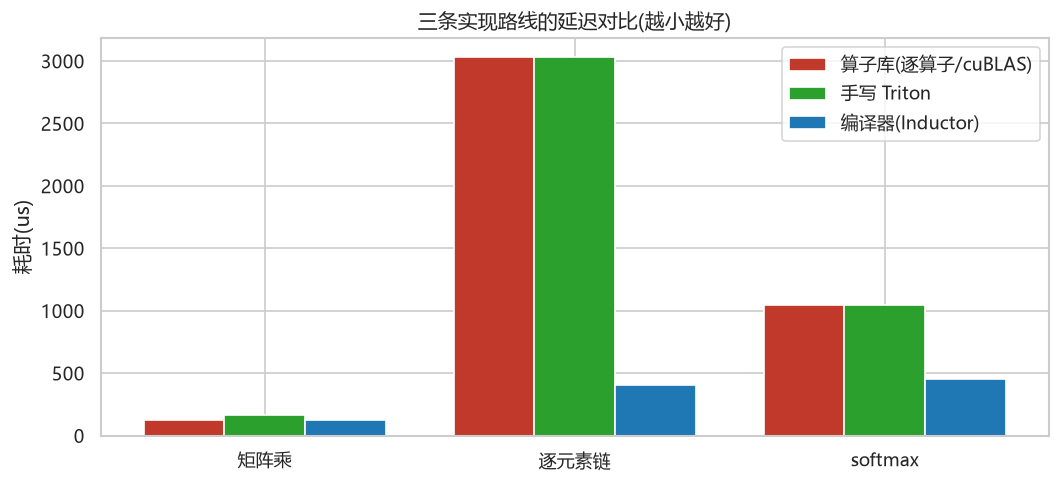

In [5]:
# 汇总三组数据并可视化
data = [
    ("矩阵乘", t_cublas, t_triton, t_inductor),
    ("逐元素链", t_chain_lib, t_chain_lib, t_chain_ind),   # 逐元素无独立"手写triton",用库近似
    ("softmax", t_soft_lib, t_soft_tri, t_soft_ind),
]
labels = ["矩阵乘", "逐元素链", "softmax"]
lib_t = [d[1] for d in data]; tri_t = [d[2] for d in data]; ind_t = [d[3] for d in data]

xpos = np.arange(len(labels)); wd = 0.26
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(xpos - wd, [v * 1000 for v in lib_t], wd, label="算子库(逐算子/cuBLAS)", color="#c0392b")
ax.bar(xpos, [v * 1000 for v in tri_t], wd, label="手写 Triton", color="#2ca02c")
ax.bar(xpos + wd, [v * 1000 for v in ind_t], wd, label="编译器(Inductor)", color="#1f77b4")
ax.set_xticks(xpos); ax.set_xticklabels(labels); ax.set_ylabel("耗时(us)")
ax.set_title("三条实现路线的延迟对比(越小越好)")
ax.legend(); plt.tight_layout()

💾 预生成实测数据给配套 App。

In [6]:
# 保存给配套 App
payload = [{"op": l, "lib_ms": round(lb, 3), "triton_ms": round(tr, 3), "inductor_ms": round(inn, 3)}
           for l, lb, tr, inn in [("矩阵乘", t_cublas, t_triton, t_inductor),
                                  ("逐元素链", t_chain_lib, t_chain_lib, t_chain_ind),
                                  ("softmax", t_soft_lib, t_soft_tri, t_soft_ind)]]
with open("oplib_69.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
print("已保存 oplib_69.json")

已保存 oplib_69.json


## 3️⃣ 配套 App:选择对比 🎛️

同目录的 `app_69_oplib_vs_compiler.py` 把选择做成交互:选**运算**(矩阵乘 / 逐元素链 / softmax)、
切换延迟或加速比指标,并给出"何时该选谁"的建议:

```bash
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_69_oplib_vs_compiler.py
```

浏览器打开 **http://localhost:8501**。完整源码如下:

📜 运行本 cell 覆盖写入 `app_69_oplib_vs_compiler.py`,保证 notebook 与 app 一致。

In [7]:
%%writefile app_69_oplib_vs_compiler.py
# -*- coding: utf-8 -*-
# app_69_oplib_vs_compiler.py — 算子库 vs 编译器:选择对比 ⚖️
import streamlit as st
import plotly.graph_objects as go
import os, json

st.set_page_config(page_title="算子库 vs 编译器 ⚖️", layout="wide")
st.title("⚖️ 第 69 课 · 算子库 vs 编译器:选择对比")

st.markdown("""
写高性能 kernel 有两条路:**算子库**(cuBLAS / cuDNN / CUTLASS,人工精调、覆盖常见算子)和
**JIT 编译器**(Triton / Inductor,自动生成、灵活覆盖任意组合)。下方选一个运算,对比两条路的
延迟与各自优劣,并看何时该选谁。
""")

# ---------------- 实测数据(notebook 生成的 oplib_69.json)----------------
DATA = [
    {"op": "矩阵乘", "lib_ms": 1.220, "triton_ms": 1.167, "inductor_ms": 1.203},
    {"op": "逐元素链", "lib_ms": 2.770, "triton_ms": 0.408, "inductor_ms": 0.410},
    {"op": "softmax", "lib_ms": 1.036, "triton_ms": 0.455, "inductor_ms": 0.455},
]
_j = os.path.join(os.path.dirname(os.path.abspath(__file__)), "oplib_69.json")
if os.path.exists(_j):
    try:
        DATA = json.load(open(_j, encoding="utf-8"))
    except Exception:
        pass

st.sidebar.header("🎛️ 参数")
op = st.sidebar.selectbox("运算", [d["op"] for d in DATA])
metric = st.sidebar.radio("查看指标", ["延迟(ms)", "相对算子库加速比"], horizontal=True)
show_advice = st.sidebar.checkbox("显示选择建议", value=True)
st.sidebar.caption("矩阵乘 cuBLAS 极强(编译器难超越);逐元素/融合类编译器更灵活,往往更快。")

row = next(d for d in DATA if d["op"] == op)
lib, tri, ind = row["lib_ms"], row["triton_ms"], row["inductor_ms"]

c1, c2, c3 = st.columns(3)
c1.metric("算子库(cuBLAS)", f"{lib:.3f} ms")
c2.metric("手写 Triton", f"{tri:.3f} ms")
c3.metric("编译器(Inductor)", f"{ind:.3f} ms")

fig = go.Figure()
if metric == "延迟(ms)":
    fig.add_bar(x=["算子库(cuBLAS)", "手写 Triton", "编译器(Inductor)"],
                y=[lib, tri, ind], marker_color=["#c0392b", "#2ca02c", "#1f77b4"],
                text=[f"{lib:.3f}", f"{tri:.3f}", f"{ind:.3f}"], textposition="outside")
    fig.update_layout(title=f"{op}:三条路的延迟对比", yaxis_title="ms")
else:
    base = min(lib, tri, ind)
    fig.add_bar(x=["算子库(cuBLAS)", "手写 Triton", "编译器(Inductor)"],
                y=[lib / base, tri / base, ind / base], marker_color=["#c0392b", "#2ca02c", "#1f77b4"],
                text=[f"{lib/base:.2f}x", f"{tri/base:.2f}x", f"{ind/base:.2f}x"], textposition="outside")
    fig.update_layout(title=f"{op}:相对最快方案的耗时倍数(越小越快)", yaxis_title="倍数")
fig.update_layout(height=380, margin=dict(l=10, r=10, t=50, b=10))
st.plotly_chart(fig, use_container_width=True)

if show_advice:
    st.subheader("🧭 何时选谁")
    if op == "矩阵乘":
        st.success("**矩阵乘 → 优先算子库(cuBLAS)**。它被精调多年、逼近硬件峰值,编译器(经 Triton)通常只能打平或略慢。")
        st.info("若算子形状固定且极端,可手写 Triton/CUTLASS 超越 cuBLAS(见本课实测,tile 调好也能反超)。")
    else:
        st.success("**逐元素 / 融合类 → 优先编译器(Triton/Inductor)**。算子库只覆盖常见算子,自定义组合时编译器自动融合更快。")
        st.info("算子库对『单个常见算子』很稳,但对『你的特殊组合』无能为力 —— 这正是编译器的用武之地。")

st.markdown("""
> 💡 **结论**:算子库=『专业厨师』,常见菜又快又好;编译器=『万能厨师』,啥菜都能做、还能帮你
> 把几道菜并成一锅。实际工程常两者混用:常见算子用库,特殊融合用编译器。
""")

Overwriting app_69_oplib_vs_compiler.py


## ✅ 本课小结

- 两条写 kernel 的路线:算子库(手工精调、覆盖常见算子)vs JIT 编译器(自动生成、覆盖任意组合)
- 矩阵乘是算子库主场:cuBLAS 逼近硬件峰值,手写 Triton 与 Inductor 通常只能打平或略慢
- 逐元素/归约是编译器主场:自动融合把多次读写压成一次,明显快过逐算子各调库
- 实际工程两者混用:常见算子用库,特殊/融合算子用编译器
- 实测(本机):矩阵乘三路接近;逐元素链与 softmax 编译器融合后快 2-6 倍

## ✍️ 动手练习

1. 把矩阵乘的 Triton tile 换成第 65 课的自动调优最优值,看能否反超 cuBLAS
2. 给逐元素链再叠几层算子,对比『逐算子库』与『编译器融合』的差距随层数如何变化
3. 思考:如果厂商只提供 cuBLAS 而没有编译器,你的自定义融合算子该怎么写?(答:手写 kernel)
4. 查一查 CUTLASS 提供的『epilogue 融合』,说说它和编译器自动融合的异同

## 🔗 延伸阅读

- [cuBLAS 文档](https://docs.nvidia.com/cuda/cublas/)
- [CUTLASS](https://github.com/NVIDIA/cutlass)
- [Triton](https://triton-lang.org/)
- [torch.compile](https://pytorch.org/docs/stable/torch.compiler.html)

---
> 🎉 恭喜完成本课!下一课见!